In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl xlrd statsmodels xgboost prophet

This cell installs necessary Python libraries required for data manipulation, analysis, and machine learning. These include `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `openpyxl`, `xlrd`, `statsmodels`, `xgboost`, and `prophet`.

### Cell 1

In [ ]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

This cell imports all the required libraries for the notebook. It includes standard libraries like `os`, `glob`, `warnings`, `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`. It also imports specific modules from `sklearn` for model selection, metrics, preprocessing, and model types like `LinearRegression` and `RandomForestRegressor`. Finally, it sets up display options and suppresses warnings.

### Cell 2

In [ ]:
DATA_ROOT_CANDIDATES = ['/content/content', '/content']

def resolve_data_root():
    for candidate in DATA_ROOT_CANDIDATES:
        if os.path.isdir(candidate):
            return candidate
    return '/content'

DATA_DIR = resolve_data_root()
print(f'Using data directory: {DATA_DIR}')
print('Files in the current directory:')
for path in sorted(glob.glob(os.path.join(DATA_DIR, '*'))):
    print(os.path.basename(path))


Using data directory: /content/content
Files in the current directory:
Master_olive.csv


This cell defines a function to resolve the data directory and then prints the path being used. It also lists all files found within that directory, confirming the presence of `Master_olive.csv`. This helps in locating the dataset for loading.

### Cell 3

In [ ]:
candidate_paths = glob.glob(os.path.join(DATA_DIR, '**', 'Master_olive.csv'), recursive=True)
if not candidate_paths:
    raise FileNotFoundError('Master_olive.csv was not found under the Colab upload folder.')

master_path = candidate_paths[0]
master_olive_df = pd.read_csv(master_path)
print('Loaded Master_olive.csv')
print('Shape:', master_olive_df.shape)

Loaded Master_olive.csv
Shape: (10814, 50)


This cell searches for the `Master_olive.csv` file within the resolved data directory and loads it into a pandas DataFrame named `master_olive_df`. It then prints the shape of the DataFrame (number of rows and columns), indicating successful loading.

### Cell 4

In [ ]:
print('Columns:')
print(list(master_olive_df.columns))

print('Dtypes:')
print(master_olive_df.dtypes)

print('Summary statistics:')
display(master_olive_df.describe(include='all').transpose())

print('Top missing values per column:')
display(master_olive_df.isna().sum().sort_values(ascending=False).head(20))

display(master_olive_df.head(10))


Columns:
['source_dataset', 'record_type', 'date', 'year', 'month', 'product', 'quantity_sold', 'price', 'cost', 'revenue', 'stock', 'domain_code', 'domain', 'area_code_m49', 'area', 'element_code', 'element', 'item_code_cpc', 'item', 'year_code', 'unit', 'value', 'flag', 'flag_description', 'item_code_fbs', 'feature_id', 'name', 'country', 'olive_varieties', 'oil_type', 'maximum_yield_kg_ha', 'irrigation', 'maximum_planting_density_n_ha', 'yield_in_oil_pct', 'maximum_acidity_g_100g', 'maximum_peroxide_value_meq_02_kg', 'k232_max', 'k268_max', 'k270_max', 'delta_k_max', 'link', 'administrative_units', 'date_of_application', 'date_of_publication', 'date_of_registration', 'price_developments_for_olive_oil', 'haverst_period', 'product_type', 'indicator', 'tonnes']
Dtypes:
source_dataset                       object
record_type                          object
date                                 object
year                                float64
month                               float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
source_dataset,10814,7,statistics,9886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,10814,5,summary,9886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,60,60,2021-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,10814.0,NaN,NaN,NaN,2022.225171,5.21186,1961.0,2022.0,2023.0,2024.0,2025.0
month,10814.0,NaN,NaN,NaN,6.453209,3.436222,1.0,3.0,6.0,9.0,12.0
product,60,1,Olive Oil,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity_sold,10814.0,NaN,NaN,NaN,121.045774,26.455832,33.0,99.0,120.0,143.0,202.0
price,10814.0,NaN,NaN,NaN,19.307709,2.957419,10.0,17.2325,19.06,21.21,32.37
cost,10814.0,NaN,NaN,NaN,12.200146,2.081166,5.5,10.72,12.055,13.53,21.92
revenue,10814.0,NaN,NaN,NaN,2339.82753,636.330083,541.53,1868.935,2337.92,2737.99,5719.05


Top missing values per column:


,0
price_developments_for_olive_oil,10802
k268_max,10800
yield_in_oil_pct,10798
delta_k_max,10754
product,10754
date,10754
maximum_planting_density_n_ha,10704
maximum_yield_kg_ha,10692
k232_max,10660
k270_max,10648


,source_dataset,record_type,date,year,month,product,quantity_sold,price,cost,revenue,...,link,administrative_units,date_of_application,date_of_publication,date_of_registration,price_developments_for_olive_oil,haverst_period,product_type,indicator,tonnes
0,olive_oil_dataset,sales,2021-01-01,2021.0,1.0,Olive Oil,157.0,22.40,13.66,3516.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,olive_oil_dataset,sales,2021-02-01,2021.0,2.0,Olive Oil,147.0,15.34,10.78,2254.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,olive_oil_dataset,sales,2021-03-01,2021.0,3.0,Olive Oil,143.0,18.06,10.10,2582.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,olive_oil_dataset,sales,2021-04-01,2021.0,4.0,Olive Oil,131.0,16.29,11.06,2133.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,olive_oil_dataset,sales,2021-05-01,2021.0,5.0,Olive Oil,123.0,18.44,12.16,2268.12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,olive_oil_dataset,sales,2021-06-01,2021.0,6.0,Olive Oil,61.0,16.23,10.70,990.03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,olive_oil_dataset,sales,2021-07-01,2021.0,7.0,Olive Oil,111.0,17.66,11.00,1960.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,olive_oil_dataset,sales,2021-08-01,2021.0,8.0,Olive Oil,86.0,16.81,10.23,1445.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,olive_oil_dataset,sales,2021-09-01,2021.0,9.0,Olive Oil,100.0,21.15,13.42,2115.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,olive_oil_dataset,sales,2021-10-01,2021.0,10.0,Olive Oil,105.0,17.64,12.48,1852.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This cell performs initial data inspection:
- It prints all column names.
- It displays the data types of each column (`dtypes`).
- It shows summary statistics for all columns, including count, mean, std, min, max, and unique values for object types. This gives a quick overview of data distribution and completeness.
- It identifies and displays columns with the most missing values, crucial for data cleaning.
- Finally, it shows the first 10 rows of the DataFrame, providing a glimpse of the raw data.

### Cell 5

In [ ]:
df = master_olive_df.copy()
df.columns = [str(col).strip().lower().replace(' ', '_') for col in df.columns]

keep_columns = ['year', 'month', 'price', 'cost', 'revenue', 'stock', 'quantity_sold']
df = df[[col for col in keep_columns if col in df.columns]].copy()

for col in keep_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.drop_duplicates().reset_index(drop=True)
print('Clean working dataframe shape:', df.shape)
display(df.head(10))

Clean working dataframe shape: (10814, 7)


,year,month,price,cost,revenue,stock,quantity_sold
0,2021.0,1.0,22.40,13.66,3516.80,378.0,157.0
1,2021.0,2.0,15.34,10.78,2254.98,733.0,147.0
2,2021.0,3.0,18.06,10.10,2582.58,716.0,143.0
3,2021.0,4.0,16.29,11.06,2133.99,391.0,131.0
4,2021.0,5.0,18.44,12.16,2268.12,605.0,123.0
5,2021.0,6.0,16.23,10.70,990.03,483.0,61.0
6,2021.0,7.0,17.66,11.00,1960.26,596.0,111.0
7,2021.0,8.0,16.81,10.23,1445.66,385.0,86.0
8,2021.0,9.0,21.15,13.42,2115.00,361.0,100.0
9,2021.0,10.0,17.64,12.48,1852.20,754.0,105.0


This cell initiates the data cleaning and preparation process:
- It creates a copy of the original DataFrame (`master_olive_df`) to work with.
- It standardizes column names by converting them to lowercase, stripping whitespace, and replacing spaces with underscores.
- It selects a subset of relevant columns (`year`, `month`, `price`, `cost`, `revenue`, `stock`, `quantity_sold`) for the analysis.
- It converts these selected columns to numeric types, coercing any non-numeric values to `NaN`.
- It removes duplicate rows and resets the index. The output shows the new shape of the cleaned DataFrame and its first 10 rows, indicating that the data has been streamlined for analysis.

### Cell 6

Numeric columns: ['year', 'month', 'price', 'cost', 'revenue', 'stock', 'quantity_sold']
Variance table:


,variance
revenue,404915.973901
stock,19937.383292
quantity_sold,699.911065
year,27.163480
month,11.807623
price,8.746327
cost,4.331254


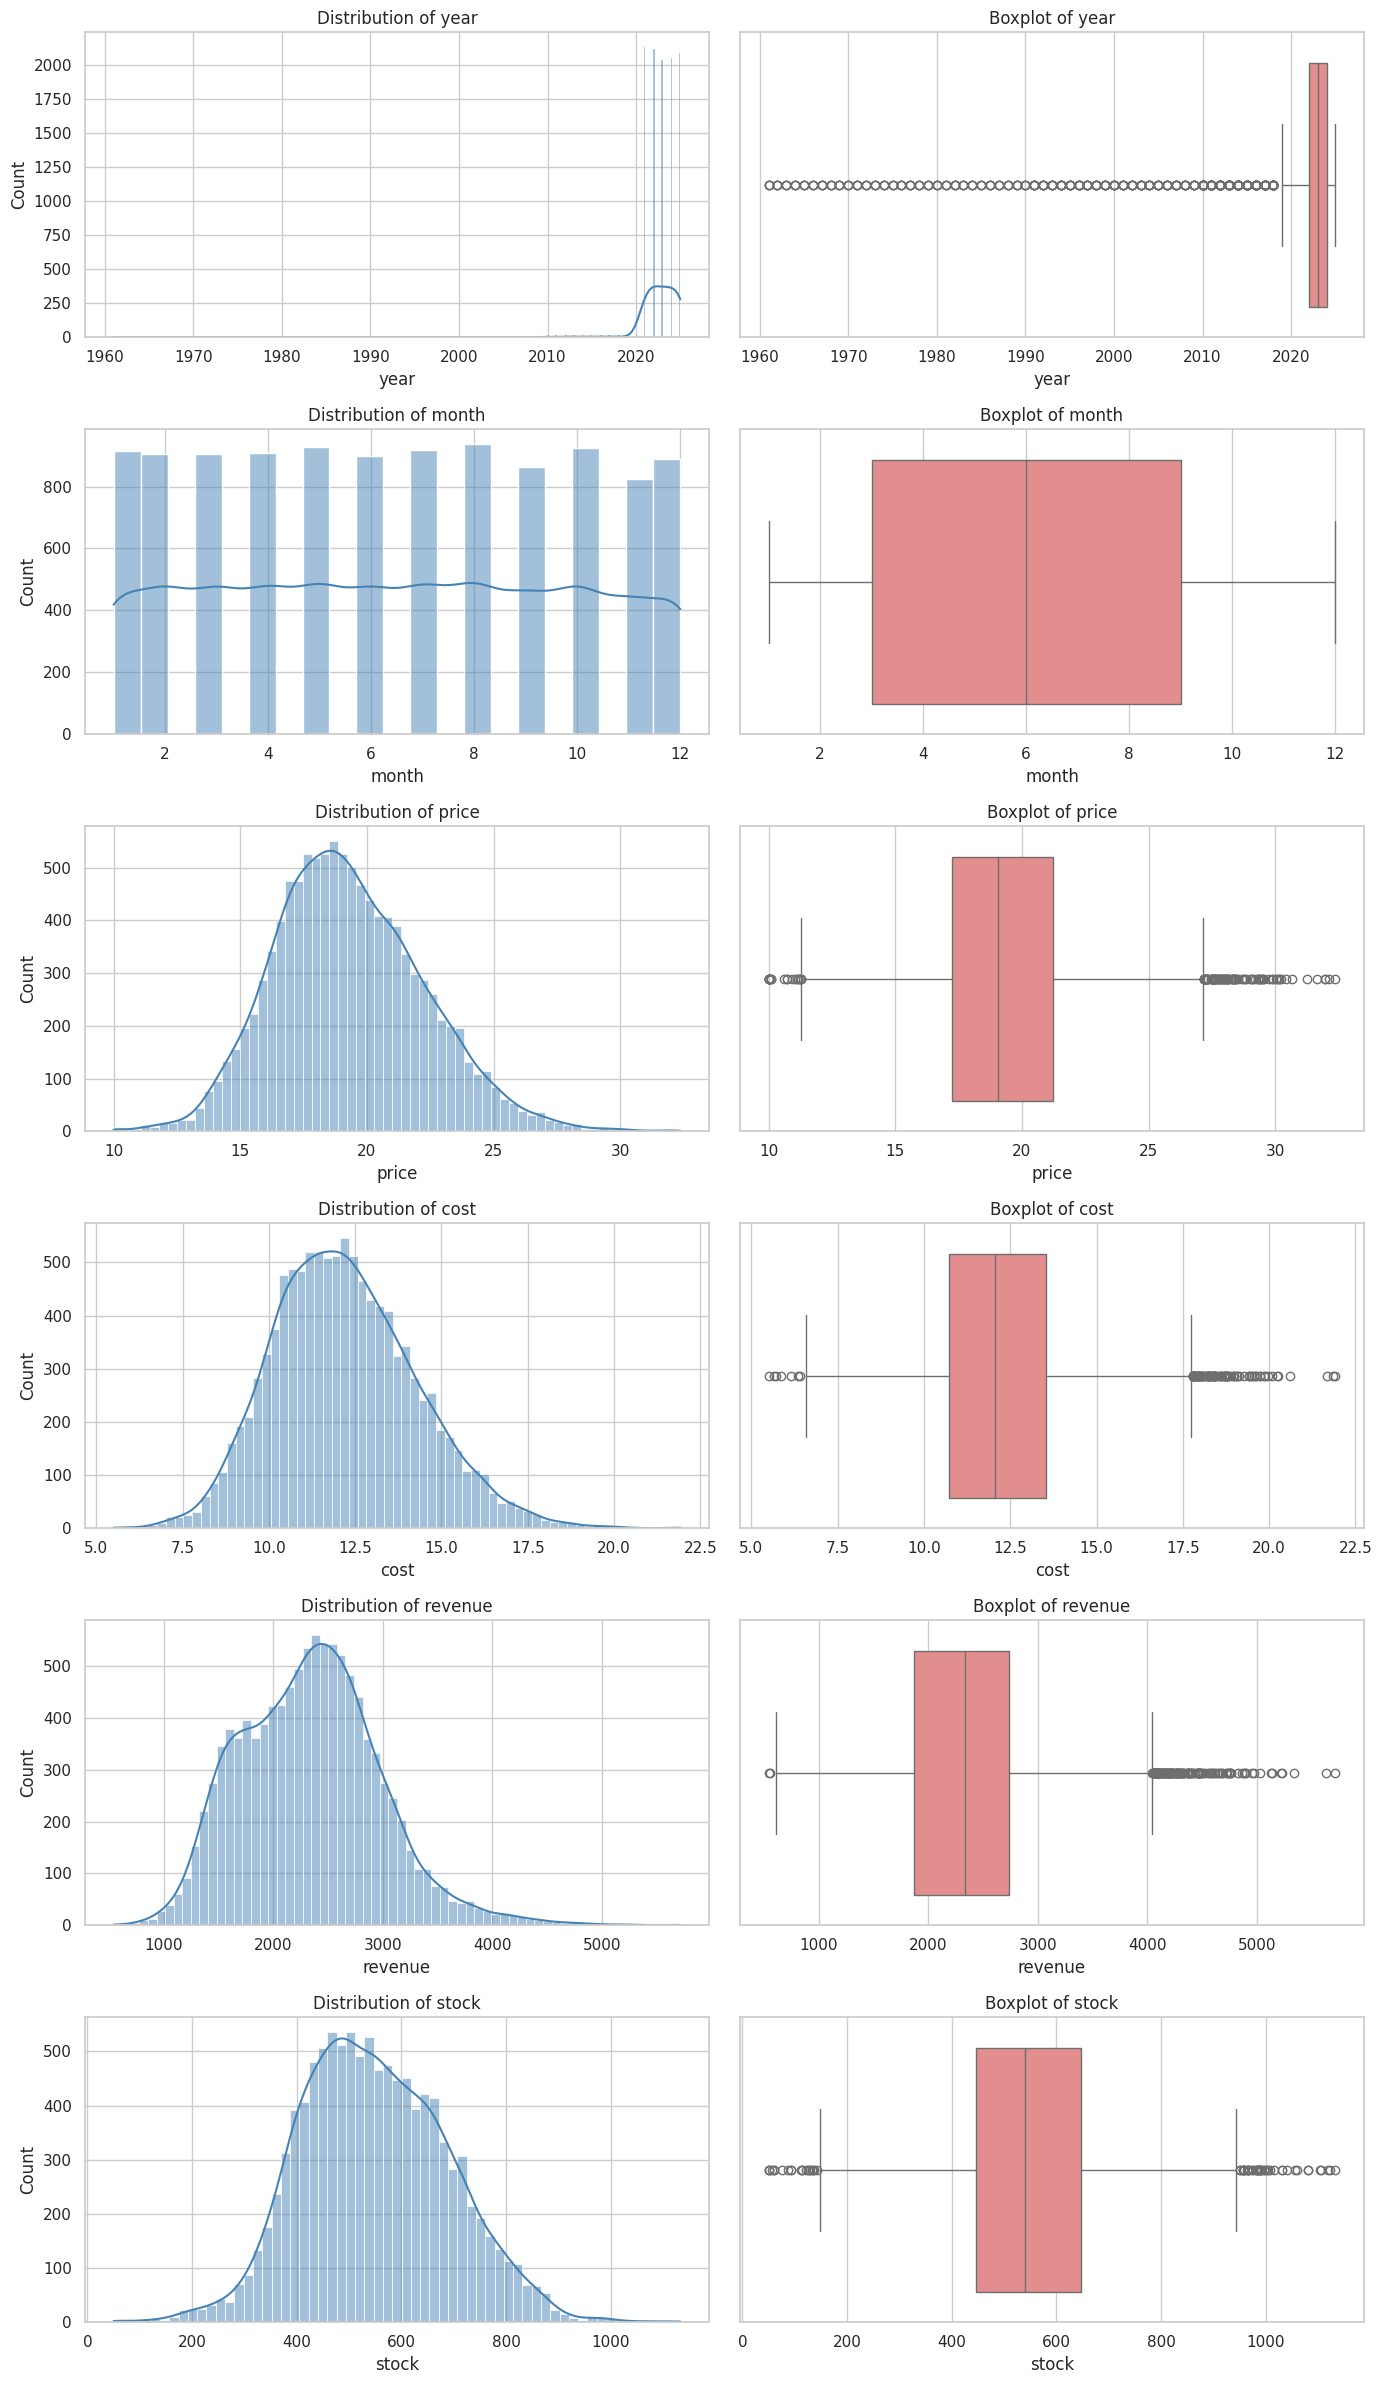

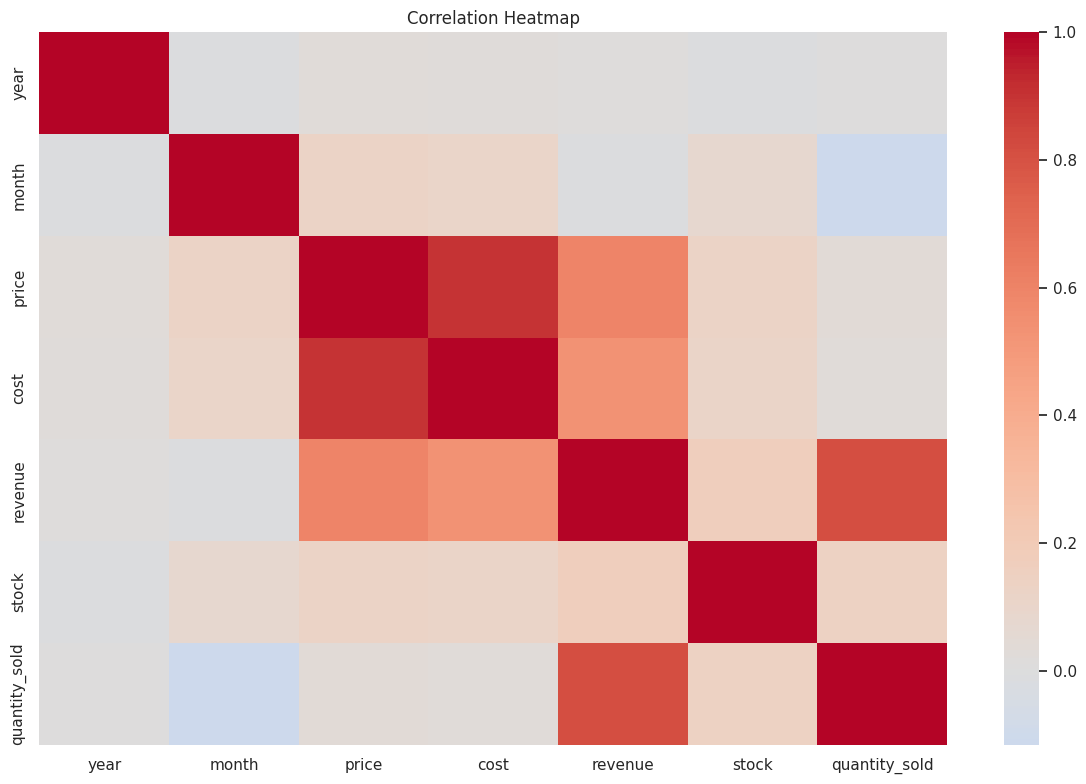

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)

if numeric_cols:
    variance_table = df[numeric_cols].var(numeric_only=True).sort_values(ascending=False)
    print('Variance table:')
    display(variance_table.to_frame(name='variance'))

    n_plots = min(6, len(numeric_cols))
    fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4 * n_plots))
    if n_plots == 1:
        axes = np.array([axes])

    for idx, col in enumerate(numeric_cols[:n_plots]):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[idx, 0], color='steelblue')
        axes[idx, 0].set_title(f'Distribution of {col}')
        sns.boxplot(x=df[col], ax=axes[idx, 1], color='lightcoral')
        axes[idx, 1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 8))
    corr = df[numeric_cols].corr(numeric_only=True)
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns available for plots.')


This cell performs exploratory data analysis (EDA) on numeric columns:
- It identifies all numeric columns in the DataFrame.
- It calculates and displays the variance for each numeric column, giving an idea of data spread.
- It generates histograms and box plots for the top numeric columns (up to 6), visualizing their distributions and identifying potential outliers.
- It creates a correlation heatmap to show the relationships between all numeric variables. This helps in understanding dependencies and multicollinearity within the dataset.

### Cell 7

Price-focused dataframe shape: (10814, 7)


,year,month,price,cost,revenue,stock,quantity_sold
0,2021.0,1.0,22.40,13.66,3516.80,378.0,157.0
1,2021.0,2.0,15.34,10.78,2254.98,733.0,147.0
2,2021.0,3.0,18.06,10.10,2582.58,716.0,143.0
3,2021.0,4.0,16.29,11.06,2133.99,391.0,131.0
4,2021.0,5.0,18.44,12.16,2268.12,605.0,123.0
5,2021.0,6.0,16.23,10.70,990.03,483.0,61.0
6,2021.0,7.0,17.66,11.00,1960.26,596.0,111.0
7,2021.0,8.0,16.81,10.23,1445.66,385.0,86.0
8,2021.0,9.0,21.15,13.42,2115.00,361.0,100.0
9,2021.0,10.0,17.64,12.48,1852.20,754.0,105.0


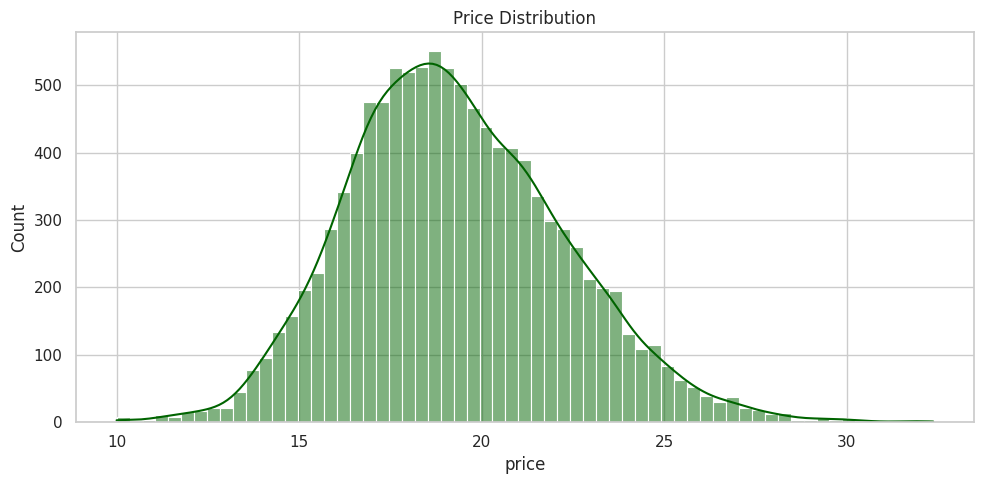

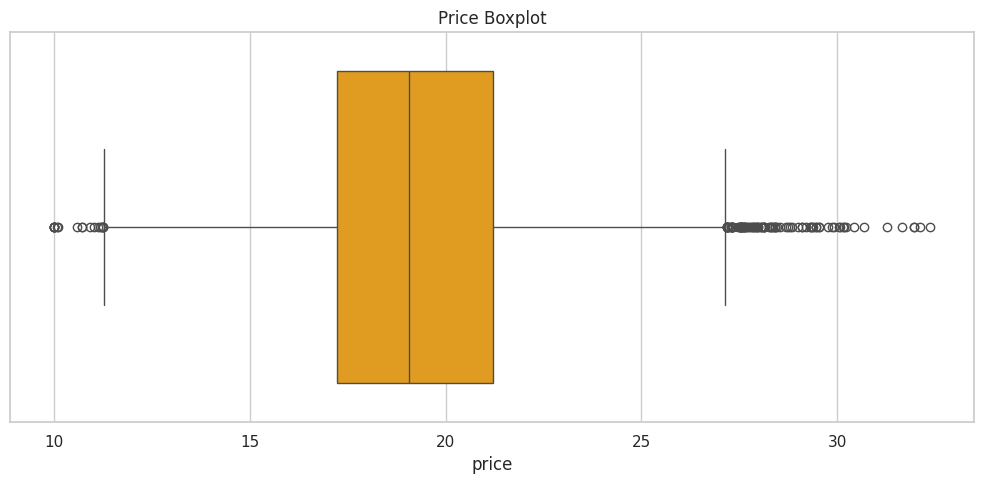

In [ ]:
price_df = df.copy()

if 'price' in price_df.columns:
    price_df = price_df[price_df['price'].notna()]

price_df = price_df[[col for col in ['year', 'month', 'price', 'cost', 'revenue', 'stock', 'quantity_sold'] if col in price_df.columns]].copy()

print('Price-focused dataframe shape:', price_df.shape)
display(price_df.head(10))

if 'price' in price_df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(price_df['price'], kde=True, color='darkgreen')
    plt.title('Price Distribution')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(x=price_df['price'], color='orange')
    plt.title('Price Boxplot')
    plt.tight_layout()
    plt.show()

This cell focuses on the 'price' column for further analysis:
- It creates a new DataFrame `price_df` containing only rows where the 'price' is not null.
- It selects relevant columns for price prediction.
- It then displays the shape and first 10 rows of this price-focused DataFrame.
- Finally, it generates a histogram and a box plot for the 'price' column, visualizing its distribution and potential outliers, similar to the general numeric column EDA but specifically for the target variable.

### Cell 8

Model dataframe shape: (10814, 7)


,year,month,price,cost,revenue,stock,quantity_sold
0,2021.0,1.0,22.40,13.66,3516.80,378.0,157.0
1,2021.0,2.0,15.34,10.78,2254.98,733.0,147.0
2,2021.0,3.0,18.06,10.10,2582.58,716.0,143.0
3,2021.0,4.0,16.29,11.06,2133.99,391.0,131.0
4,2021.0,5.0,18.44,12.16,2268.12,605.0,123.0
5,2021.0,6.0,16.23,10.70,990.03,483.0,61.0
6,2021.0,7.0,17.66,11.00,1960.26,596.0,111.0
7,2021.0,8.0,16.81,10.23,1445.66,385.0,86.0
8,2021.0,9.0,21.15,13.42,2115.00,361.0,100.0
9,2021.0,10.0,17.64,12.48,1852.20,754.0,105.0


Linear Regression -> MAE: 0.4264 | RMSE: 0.5877 | R2: 0.9619
Random Forest Regressor -> MAE: 0.2121 | RMSE: 0.3917 | R2: 0.9831


,actual_price,linear_regression_pred,random_forest_pred
0,17.55,18.485082,18.364833
1,17.81,17.763452,17.804067
2,24.68,22.801004,24.154133
3,20.81,20.737701,20.805967
4,18.44,18.194747,18.486133
5,16.06,15.515753,16.073000
6,21.75,21.503561,21.672533
7,16.97,16.499574,16.886233
8,11.50,10.041291,11.883133
9,16.31,15.510182,16.354233


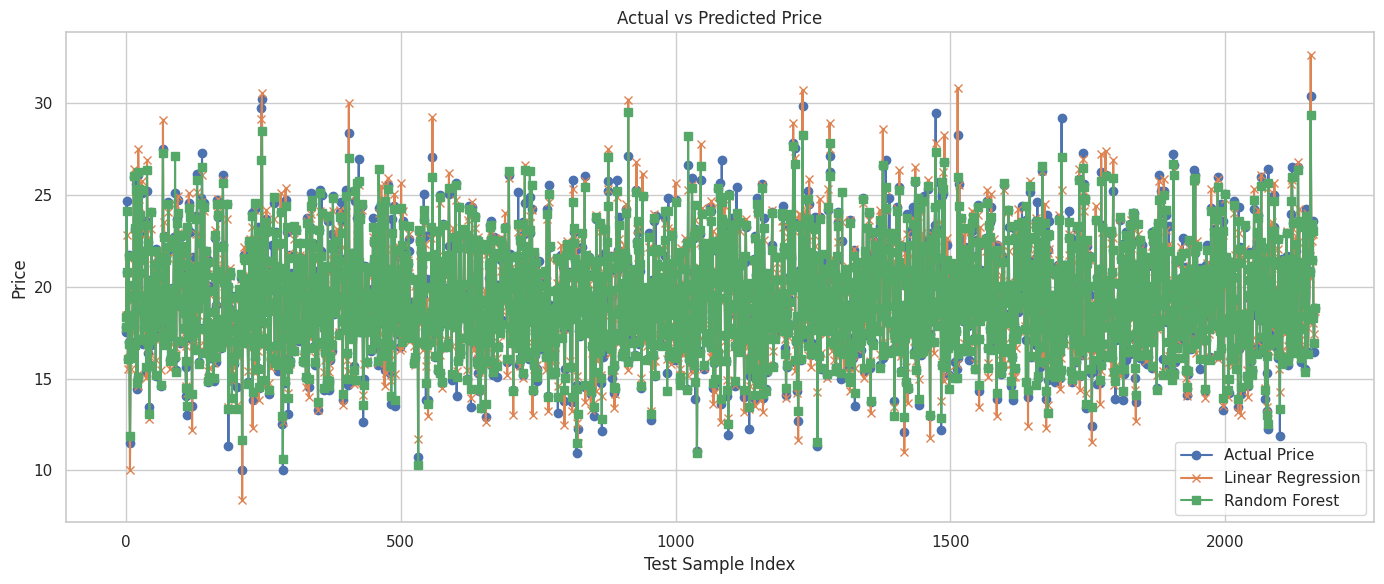

In [ ]:
model_df = price_df.dropna().reset_index(drop=True)
print('Model dataframe shape:', model_df.shape)
display(model_df.head(10))

X = model_df.drop(columns=['price'])
y = model_df['price']

split_index = int(len(model_df) * 0.8)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)
rf_predictions = random_forest_model.predict(X_test)

def regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{model_name} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}')

regression_metrics(y_test, linear_predictions, 'Linear Regression')
regression_metrics(y_test, rf_predictions, 'Random Forest Regressor')

comparison_df = pd.DataFrame({
    'actual_price': y_test.values,
    'linear_regression_pred': linear_predictions,
    'random_forest_pred': rf_predictions,
})

display(comparison_df.head(10))

plt.figure(figsize=(14, 6))
plt.plot(comparison_df['actual_price'].values, label='Actual Price', marker='o')
plt.plot(comparison_df['linear_regression_pred'].values, label='Linear Regression', marker='x')
plt.plot(comparison_df['random_forest_pred'].values, label='Random Forest', marker='s')
plt.title('Actual vs Predicted Price')
plt.xlabel('Test Sample Index')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

This cell prepares the data for modeling and trains two regression models:
- It drops any remaining rows with missing values from `price_df` to create `model_df`, which is then split into features (`X`) and target (`y`).
- The data is split into training and testing sets (80% train, 20% test) based on chronological order using `iloc`.
- Two models are defined: a `LinearRegression` model (within a `Pipeline` for scaling) and a `RandomForestRegressor`.
- Both models are trained on the training data (`X_train`, `y_train`).
- Predictions are made on the test set (`X_test`).
- A `regression_metrics` function calculates and prints Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2) for both models. The Random Forest model shows better performance with lower MAE/RMSE and higher R2.
- A comparison DataFrame is created to show actual vs. predicted prices for both models.
- Finally, a plot visualizes the actual prices against the predictions from both models on the test set, allowing for a visual comparison of their performance.

### Cell 9

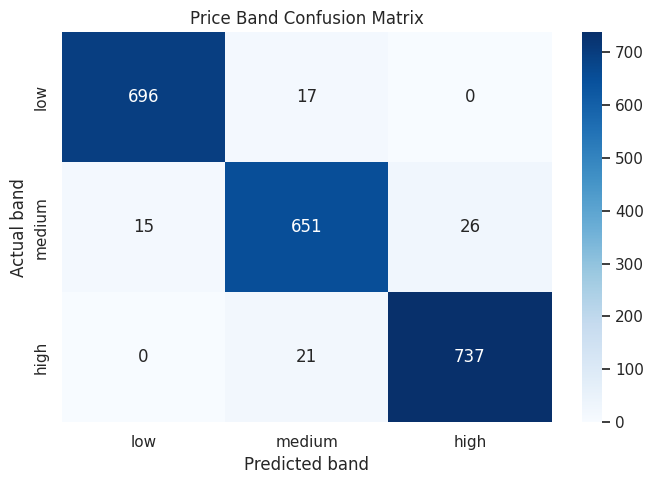

In [ ]:
bin_edges = np.quantile(model_df['price'].dropna(), [0, 1/3, 2/3, 1])
bin_edges[0] = bin_edges[0] - 1e-9
bin_edges[-1] = bin_edges[-1] + 1e-9

true_bins = pd.cut(y_test, bins=bin_edges, labels=['low', 'medium', 'high'], include_lowest=True)
pred_bins = pd.cut(pd.Series(rf_predictions, index=y_test.index), bins=bin_edges, labels=['low', 'medium', 'high'], include_lowest=True)

labels = ['low', 'medium', 'high']
conf_matrix_df = pd.crosstab(true_bins.astype(str), pred_bins.astype(str), dropna=False)
conf_matrix_df = conf_matrix_df.reindex(index=labels, columns=labels, fill_value=0)
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues')
plt.title('Price Band Confusion Matrix')
plt.xlabel('Predicted band')
plt.ylabel('Actual band')
plt.tight_layout()
plt.show()

This cell evaluates the Random Forest model's ability to predict price bands:
- It defines three price bands ('low', 'medium', 'high') using quantiles of the 'price' column.
- It then categorizes the actual test prices (`y_test`) and the Random Forest predictions (`rf_predictions`) into these bands.
- A confusion matrix is generated and visualized as a heatmap, showing how well the predicted price bands match the actual price bands. The diagonal elements represent correct classifications, indicating good performance across the price categories.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

band_accuracy = accuracy_score(true_bins.astype(str), pred_bins.astype(str))
band_f1_weighted = f1_score(true_bins.astype(str), pred_bins.astype(str), average='weighted')
band_f1_macro = f1_score(true_bins.astype(str), pred_bins.astype(str), average='macro')

print(f'Price-band accuracy: {band_accuracy:.4f}')
print(f'Price-band F1 weighted: {band_f1_weighted:.4f}')
print(f'Price-band F1 macro: {band_f1_macro:.4f}')

Price-band accuracy: 0.9635
Price-band F1 weighted: 0.9635
Price-band F1 macro: 0.9631


This cell calculates additional classification metrics for the price band prediction:
- It computes `accuracy_score` to show the overall proportion of correctly predicted price bands.
- It calculates `f1_score` (weighted and macro) to provide a balanced measure of precision and recall for each class, useful when class distribution might be imbalanced. The high scores indicate strong performance in classifying price into the defined bands.

### Cell 10

### Cell 11

In [ ]:
train_linear_predictions = linear_model.predict(X_train)
train_rf_predictions = random_forest_model.predict(X_train)

print('Train metrics:')
regression_metrics(y_train, train_linear_predictions, 'Linear Regression Train')
regression_metrics(y_train, train_rf_predictions, 'Random Forest Train')

print('\nTest metrics:')
regression_metrics(y_test, linear_predictions, 'Linear Regression Test')
regression_metrics(y_test, rf_predictions, 'Random Forest Test')

train_vs_test_df = pd.DataFrame({
    'split': ['train', 'test'],
    'linear_mae': [mean_absolute_error(y_train, train_linear_predictions), mean_absolute_error(y_test, linear_predictions)],
    'rf_mae': [mean_absolute_error(y_train, train_rf_predictions), mean_absolute_error(y_test, rf_predictions)],
    'linear_rmse': [np.sqrt(mean_squared_error(y_train, train_linear_predictions)), np.sqrt(mean_squared_error(y_test, linear_predictions))],
    'rf_rmse': [np.sqrt(mean_squared_error(y_train, train_rf_predictions)), np.sqrt(mean_squared_error(y_test, rf_predictions))],
    'linear_r2': [r2_score(y_train, train_linear_predictions), r2_score(y_test, linear_predictions)],
    'rf_r2': [r2_score(y_train, train_rf_predictions), r2_score(y_test, rf_predictions)],
})

display(train_vs_test_df)

Train metrics:
Linear Regression Train -> MAE: 0.4227 | RMSE: 0.5876 | R2: 0.9601
Random Forest Train -> MAE: 0.0801 | RMSE: 0.1464 | R2: 0.9975

Test metrics:
Linear Regression Test -> MAE: 0.4264 | RMSE: 0.5877 | R2: 0.9619
Random Forest Test -> MAE: 0.2121 | RMSE: 0.3917 | R2: 0.9831


,split,linear_mae,rf_mae,linear_rmse,rf_rmse,linear_r2,rf_r2
0,train,0.422719,0.080085,0.587615,0.146386,0.960147,0.997527
1,test,0.426427,0.212065,0.587667,0.391699,0.961897,0.983072


This cell provides a detailed comparison of model performance on both training and test datasets:
- It generates predictions for both Linear Regression and Random Forest models on the training set.
- It then prints and displays the MAE, RMSE, and R2 scores for both models on both the training and test sets. This comparison helps in identifying overfitting (when training performance is much better than test performance) or underfitting. The output shows that the Random Forest model performs significantly better on both train and test sets, indicating good generalization, although there's some difference between train and test for RF, suggesting a slight amount of overfitting but still strong performance.

### Cell 12

TimeSeriesSplit R2 scores: [0.95679543 0.95839858 0.96138899 0.96281099 0.96048812]
Mean CV R2: 0.9599764224453089
Std CV R2: 0.0021401043370216366


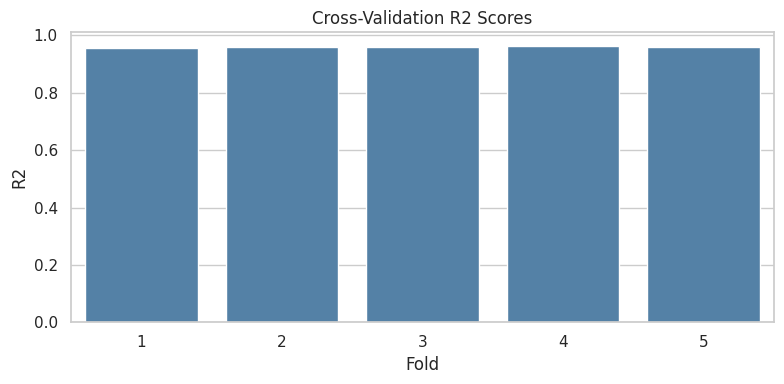

In [ ]:
cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

cv_splits = min(5, max(2, len(model_df) // 10))
tscv = TimeSeriesSplit(n_splits=cv_splits)
cv_scores = cross_val_score(cv_model, X, y, cv=tscv, scoring='r2')

print('TimeSeriesSplit R2 scores:', cv_scores)
print('Mean CV R2:', cv_scores.mean())
print('Std CV R2:', cv_scores.std())

plt.figure(figsize=(8, 4))
sns.barplot(x=list(range(1, len(cv_scores) + 1)), y=cv_scores, color='steelblue')
plt.title('Cross-Validation R2 Scores')
plt.xlabel('Fold')
plt.ylabel('R2')
plt.tight_layout()
plt.show()

This cell performs time series cross-validation for the Linear Regression model:
- It sets up a `TimeSeriesSplit` with a dynamic number of splits, suitable for time-dependent data.
- It then uses `cross_val_score` to evaluate the Linear Regression model across these splits, calculating the R2 score for each fold.
- The individual R2 scores, mean R2, and standard deviation of R2 scores are printed, giving a more robust estimate of the model's performance and stability.
- A bar plot visualizes the R2 scores for each cross-validation fold, illustrating the consistency of the model's performance over different time periods.

### Cell 13

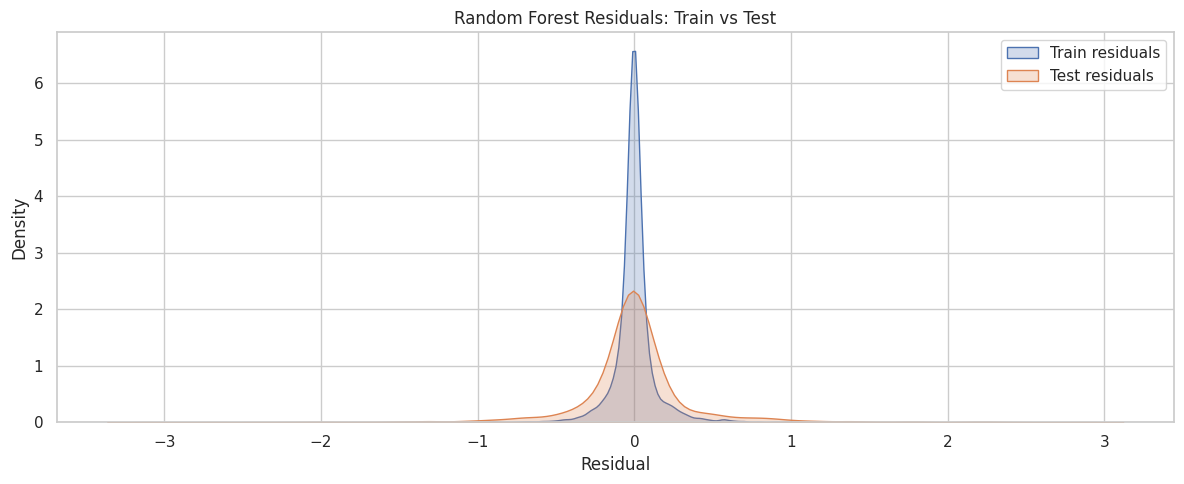

In [ ]:
rf_residuals_train = y_train.values - train_rf_predictions
rf_residuals_test = y_test.values - rf_predictions

plt.figure(figsize=(12, 5))
sns.kdeplot(rf_residuals_train, label='Train residuals', fill=True)
sns.kdeplot(rf_residuals_test, label='Test residuals', fill=True)
plt.title('Random Forest Residuals: Train vs Test')
plt.xlabel('Residual')
plt.legend()
plt.tight_layout()
plt.show()

This cell visualizes the residuals of the Random Forest model:
- It calculates the residuals (actual minus predicted values) for both the training and test sets.
- A Kernel Density Estimate (KDE) plot is generated, showing the distribution of these residuals for both sets. Ideally, residuals should be normally distributed around zero. This plot helps in assessing the model's assumptions and identifying any systematic errors or biases in the predictions. The plot shows the residuals are centered around zero for both train and test, which is a good sign for the model.

In [ ]:
# Cell: export model artifacts
import joblib
import json
import os

EXPORT_DIR = "/content/model_artifacts"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) model
joblib.dump(random_forest_model, f"{EXPORT_DIR}/price_model.joblib")

# 2) feature order used at prediction time
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, f"{EXPORT_DIR}/feature_columns.joblib")

# 3) metadata for dashboard display / versioning
metadata = {
    "model_name": "random_forest_price_model",
    "version": "v1",
    "target": "price",
    "features": feature_columns,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
}
with open(f"{EXPORT_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Exported files:")
print(os.listdir(EXPORT_DIR))

Exported files:
['feature_columns.joblib', 'price_model.joblib', 'metadata.json']


In [ ]:
from google.colab import files
files.download("/content/model_artifacts/price_model.joblib")
files.download("/content/model_artifacts/feature_columns.joblib")
files.download("/content/model_artifacts/metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>